<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/Project_1_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Project 1 (Potential Solution) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1.  [Introduction](#Introduction)

3.  [Implementing the State](#State)

4.  [Changing the State](#Change)

5.  [Stepping Forward In Time](#Time)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Introduction"></a>

---

<font size = 6> <b> 1. Introduction </b> </font>

---

<font size = 5> <b> 1.1 Disclaimer </b> </font>

This is a potential solution to Project 1. <b>It is not the only solution.</b> As with all things in computational science, there is more than one way to get a correct solution.

In [1]:
##=============================================================================================##
## Import Libraries                                                                            ##
##=============================================================================================##

import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
##=============================================================================================##
## Define the Simulation's Parameters:                                                         ##
##=============================================================================================##

parameters = pd.Series({
    "money_initial"  : 100,       # The gambler starts with 100 dollars.
    "max_steps"      : 80,        # The gambler can bet a maximum of 80 times.
    "win_multiplier" : 36,        # A successful bet results in a 36x return.
    "p_win"          : 1 / 38,    # The probability of winning any bet is 1 / 38.
    "bet_type"       : "half" # The type of bet is constant.
})

display(parameters)

,0
money_initial,100
max_steps,80
win_multiplier,36
p_win,0.026316
bet_type,half


In [48]:
##=============================================================================================##
## Define the Change Function:                                                                 ##
##=============================================================================================##

def change_function(state, bet, p_win, win_multiplier, debug = False):

  # Create a random number to simulate the roulette spin:

  spin_outcome = npr.random()

  # Save the original money amount for debug purposes:

  money_old = state.money

  # Remove the bet from the remaining money:

  state.money = state.money - bet

  # Check to see if the bet was won:

  if (spin_outcome < p_win):

    # Add the bet times the win multiplier to the remaining money:

    state.money = state.money + (bet * win_multiplier)

  # Check the internal values if debug is True:

  if (debug == True):

    print("Initial Money: " + str(money_old))
    print()

    print("Win Probability: " + str(p_win))
    print("Spin Outcome: " + str(spin_outcome))
    print()

    if (spin_outcome < p_win):

      print("Bet Won!")
      print()

    else:

      print("Bet Lost!")
      print()

    print("Final Money: ", state.money)

  # Return the updated system state:

  return state

In [66]:
##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation(parameters):

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Set the initial money:

  money_initial = float(parameters.money_initial)

  # Set the maximum number of bets:

  max_steps = int(parameters.max_steps)

  # Set the win multiplier:

  win_multiplier = parameters.win_multiplier

  # Set the probability of winning a bet:

  p_win = parameters.p_win

  # Set the bet type:

  bet_type = parameters.bet_type

  ##===========================================================================================##
  ## Create the System's Initial State and State History:                                      ##
  ##===========================================================================================##

  # Create a Pandas Series to store the system's state:

  system_state = pd.Series({"money" : money_initial})

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'Remaining Money'

  state_history.index.name = 'Bet #'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = system_state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  for i in range(max_steps):

    # Set the bet amount:

    if (bet_type == "constant"): bet = 2.0

    elif (bet_type == "half"): bet = np.round(system_state.money / 2.0, 2)

    else: raise ValueError("Bet type must be 'constant' or 'half'.")

    # If there is insufficient money to place the bet, break from the loop:

    if ((system_state.money < bet) or (system_state.money < 0.01)): break

    # Get the state of the system for the current time step:

    system_state = change_function(system_state, bet, p_win, win_multiplier)

    # Store the new system state in the state_history DataFrame:

    state_history.loc[i + 1] = system_state.T

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

Parameters:


,0
money_initial,100
max_steps,80
win_multiplier,36
p_win,0.026316
bet_type,constant




Final System State:

Money Remaining: 84.0



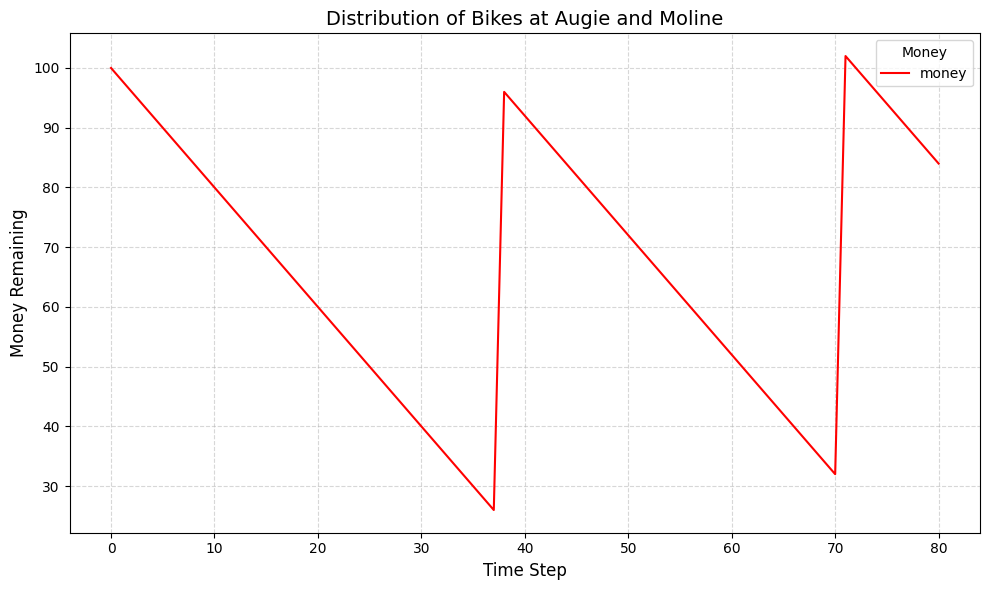

In [67]:
##=============================================================================================##
## Define the Simulation's Parameters:                                                         ##
##=============================================================================================##

parameters = pd.Series({
    "money_initial"  : 100,       # The gambler starts with 100 dollars.
    "max_steps"      : 80,        # The gambler can bet a maximum of 80 times.
    "win_multiplier" : 36,        # A successful bet results in a 36x return.
    "p_win"          : 1 / 38,    # The probability of winning any bet is 1 / 38.
    "bet_type"       : "constant" # The type of bet is constant.
})

print("Parameters:")
display(parameters)
print()

##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters)

print()
print("Final System State:")
print()
print("Money Remaining: " + str(simulation_history.iloc[-1, 0]))
print()

##=============================================================================================##
## Create a Graph of the System's State History:                                               ##
##=============================================================================================##

# Create the plot of the DataFrame:

ax = simulation_history.plot(
    kind = 'line',
    y = ['money'],
    color = ['red'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Distribution of Bikes at Augie and Moline", fontsize = 14)

ax.set_xlabel("Time Step", fontsize = 12)

ax.set_ylabel("Money Remaining", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha=0.5)
plt.legend(title = "Money")

plt.tight_layout()

# Display the plot:

plt.show()

Parameters:


,0
money_initial,100
max_steps,80
win_multiplier,36
p_win,0.026316
bet_type,half


<Axes: >

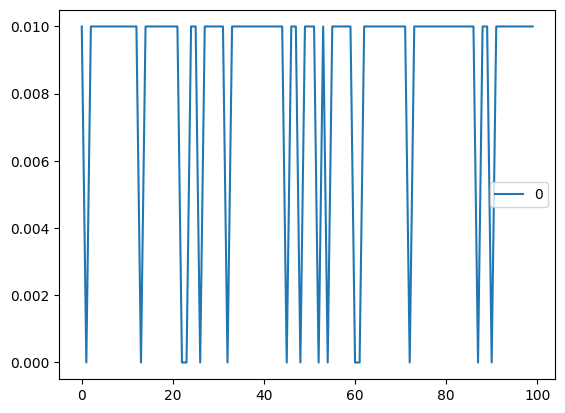

In [68]:
##=============================================================================================##
## Define the Simulation's Parameters:                                                         ##
##=============================================================================================##

parameters = pd.Series({
    "money_initial"  : 100,       # The gambler starts with 100 dollars.
    "max_steps"      : 80,        # The gambler can bet a maximum of 80 times.
    "win_multiplier" : 36,        # A successful bet results in a 36x return.
    "p_win"          : 1 / 38,    # The probability of winning any bet is 1 / 38.
    "bet_type"       : "half" # The type of bet is constant.
})

print("Parameters:")
display(parameters)
print()

##=============================================================================================##
## Create a list to store the outcome of the simulation:                                       ##
##=============================================================================================##

outcome = []

##=============================================================================================##
## Run the simulation 100 Times and Store the Outcome:                                         ##
##=============================================================================================##

for i in range (0, 100):

  simulation_history = run_simulation(parameters)

  outcome.append(simulation_history.iloc[-1, 0])

##=============================================================================================##
## Display the Outcome Results:                                                                ##
##=============================================================================================##

outcome_df = pd.DataFrame(outcome)

outcome_df.plot()
